# Lazy MLP Results Visualization

This notebook visualizes and summarizes the Stage 2 Improved MLP training results from the saved output directory, without retraining the model.

In [11]:
from pathlib import Path

# Detect project root dynamically
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL


In [12]:
# Define output directory relative to PROJECT_ROOT
output_dir = PROJECT_ROOT / "outputs" / "stage2_lazy_mlp_q25_e3"
print(f"output_dir: {output_dir}")

# Check if files exist
history_path = output_dir / "training_history.json"
args_path = output_dir / "train_args.json"
print(f"training_history.json exists: {history_path.exists()}")
print(f"train_args.json exists: {args_path.exists()}")

output_dir: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/outputs/stage2_lazy_mlp_q25_e3
training_history.json exists: True
train_args.json exists: True


In [13]:
import json

# Load training history and args
with open(history_path) as f:
    history = json.load(f)

with open(args_path) as f:
    args = json.load(f)

In [14]:
# Print loaded args and short experiment summary
print("Training Arguments:")
for key, value in args.items():
    print(f"  {key}: {value}")

print("\nExperiment Summary:")
print(f"  Manifest Type: {args['manifest_type']}")
print(f"  Epochs: {args['epochs']}")
print(f"  Batch Size: {args['batch_size']}")
print(f"  Learning Rate: {args['lr']}")
print(f"  Subset Fractions: Train {args.get('train_subset_fraction', 'N/A')}, Dev {args.get('dev_subset_fraction', 'N/A')}")

Training Arguments:
  generated_dir: data/generated
  norm_stats_path: data/generated/train/features/noisy_norm_stats.npz
  manifest_type: noisy
  train_subset_fraction: 0.25
  dev_subset_fraction: 0.25
  epochs: 3
  batch_size: 512
  lr: 0.001
  weight_decay: 1e-05
  dropout: 0.1
  num_workers: 0
  device: auto
  seed: 42
  output_dir: outputs/stage2_lazy_mlp_q25_e3

Experiment Summary:
  Manifest Type: noisy
  Epochs: 3
  Batch Size: 512
  Learning Rate: 0.001
  Subset Fractions: Train 0.25, Dev 0.25


In [15]:
# Extract train/dev loss and accuracy per epoch
train_loss = [e["loss"] for e in history["train"]]
dev_loss = [e["loss"] for e in history["dev"]]
train_acc = [e["accuracy"] for e in history["train"]]
dev_acc = [e["accuracy"] for e in history["dev"]]
epochs = list(range(1, len(train_loss) + 1))

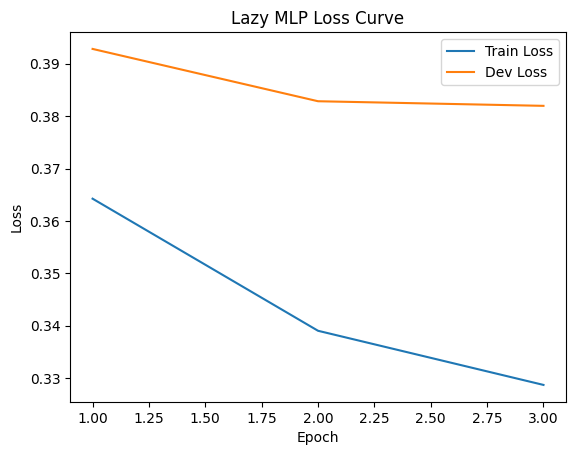

In [16]:
import matplotlib.pyplot as plt

# Plot training and dev loss curves
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, dev_loss, label="Dev Loss")
plt.legend()
plt.title("Lazy MLP Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

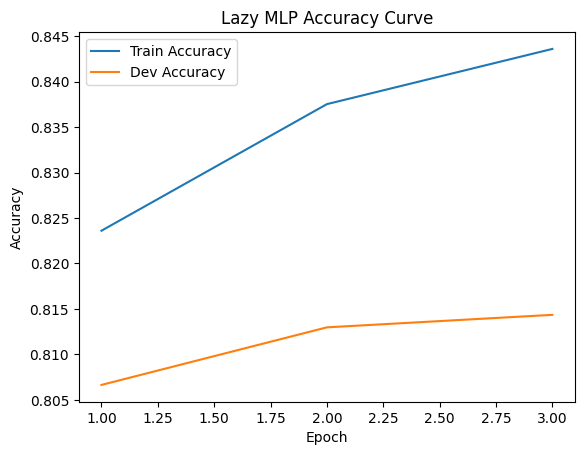

In [17]:
# Plot training and dev accuracy curves
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, dev_acc, label="Dev Accuracy")
plt.legend()
plt.title("Lazy MLP Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [18]:
# Compute and print best/final metrics
best_dev_acc = max(dev_acc)
best_epoch = dev_acc.index(best_dev_acc) + 1
final_train_acc = train_acc[-1]
final_dev_acc = dev_acc[-1]

print(f"Best Dev Accuracy: {best_dev_acc:.4f} at Epoch {best_epoch}")
print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Dev Accuracy: {final_dev_acc:.4f}")

Best Dev Accuracy: 0.8143 at Epoch 3
Final Train Accuracy: 0.8436
Final Dev Accuracy: 0.8143


In [19]:
import pandas as pd

# Create DataFrame with results
df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_loss,
    "dev_loss": dev_loss,
    "train_accuracy": train_acc,
    "dev_accuracy": dev_acc
})

In [20]:
# Display the table
df

,epoch,train_loss,dev_loss,train_accuracy,dev_accuracy
0,1,0.364241,0.392837,0.823607,0.806638
1,2,0.339017,0.382847,0.837536,0.812974
2,3,0.328679,0.381968,0.843611,0.814349


## Results Interpretation

The lazy MLP trains stably across epochs. Training loss decreases and dev accuracy improves over time. The best dev accuracy is reached at the final epoch in this experiment. This suggests that replacing offline features with lazy on-the-fly features does not break the baseline MLP pipeline.